In [83]:
from typing import Iterable
import string
import xml.etree.ElementTree as ET
from pathlib import Path
import numpy as np
from scipy.spatial import distance
import pandas as pd

In [84]:


ROUTES_DIR = Path('../data/routes')
ROUTES_DIR.exists()

True

In [85]:
tree = ET.parse(ROUTES_DIR / "routes_devtest_sliced.xml")

# Get the root element
root = tree.getroot()



In [86]:
def get_route_length(route: ET.Element):
    points = [[waypoint.attrib['x'], waypoint.attrib['y'], waypoint.attrib['z']] 
         for waypoint in route]
    
    # convert points to floats
    points = [list(map(float,p)) for p in points]

    length = 0
    for previous, current in zip(points, points[1:]):
        # print(previous, current)
        length += distance.euclidean(previous, current)
        
    return length

In [87]:
data = []
for route in root:
    route_data = route.attrib
    route_data['length'] = get_route_length(route)
    data.append(route_data)

df = pd.DataFrame(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   town    132 non-null    object 
 1   id      132 non-null    object 
 2   length  132 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.2+ KB


Min: 24.010483205375078
Max: 940.7829062194862
Avg: 327.6647942839112
Median: 285.78583318645354
Stdev: 166.27321836225153


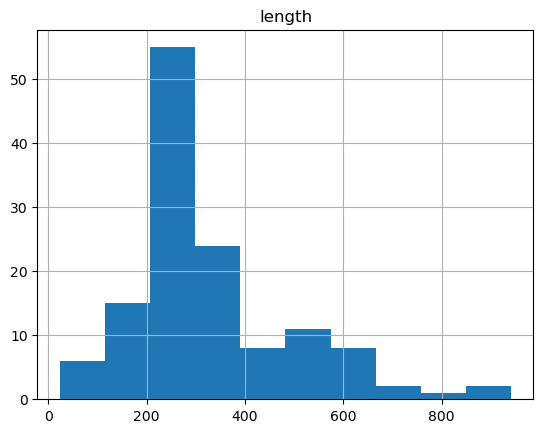

In [90]:
df.hist()
print(f"Min: {df['length'].min()}")
print(f"Max: {df['length'].max()}")
print(f"Avg: {df['length'].mean()}")
print(f"Median: {df['length'].median()}")
print(f"Stdev: {df['length'].std()}")

# ax.set_xlabel("Route length in [m]")

### SEEDS


In [15]:
from itertools import product
PRIMES = [10**9, 10**6, 10**3]
reps = range(0, 20)
fps_values = [10, 15, 20]
high_quality = [True, False]

seeds = []
for rep, fps, hq in product(reps, fps_values, high_quality):
    seed = rep*PRIMES[0] + fps*PRIMES[1] + int(hq)*PRIMES[2]
    seeds.append(seed)

print(seeds)
len(set(seeds))

[10001000, 10000000, 15001000, 15000000, 20001000, 20000000, 1010001000, 1010000000, 1015001000, 1015000000, 1020001000, 1020000000, 2010001000, 2010000000, 2015001000, 2015000000, 2020001000, 2020000000, 3010001000, 3010000000, 3015001000, 3015000000, 3020001000, 3020000000, 4010001000, 4010000000, 4015001000, 4015000000, 4020001000, 4020000000, 5010001000, 5010000000, 5015001000, 5015000000, 5020001000, 5020000000, 6010001000, 6010000000, 6015001000, 6015000000, 6020001000, 6020000000, 7010001000, 7010000000, 7015001000, 7015000000, 7020001000, 7020000000, 8010001000, 8010000000, 8015001000, 8015000000, 8020001000, 8020000000, 9010001000, 9010000000, 9015001000, 9015000000, 9020001000, 9020000000, 10010001000, 10010000000, 10015001000, 10015000000, 10020001000, 10020000000, 11010001000, 11010000000, 11015001000, 11015000000, 11020001000, 11020000000, 12010001000, 12010000000, 12015001000, 12015000000, 12020001000, 12020000000, 13010001000, 13010000000, 13015001000, 13015000000, 13020

120

In [14]:
N = 10
x = "second"
repetitions = range(N)

if x == "first":
    repetitions = repetitions[:N//2]
elif x == "second":
    repetitions = repetitions[N//2:]
for i in repetitions:
    print(i)

5
6
7
8
9
